# OmniParser v2 demo

Pipeline:
1. **YOLO** (`weights/icon_detect/model.pt`) detects UI element bounding boxes.
2. **Florence-2** uses the processor from Hugging Face (`microsoft/Florence-2-base`) and local caption weights from `weights/icon_caption_florence/`.
3. The notebook draws labeled boxes on the image, prints the classifications, and saves `annotated.png`.

This notebook is detector + caption only. OCR is not used.

In [3]:
from pathlib import Path
import numpy as np
import torch
import cv2
from PIL import Image, ImageDraw, ImageFont
from torchvision.transforms import ToPILImage
from ultralytics import YOLO
from transformers import AutoModelForCausalLM, AutoProcessor
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
WEIGHTS    = REPO_ROOT / "weights"
YOLO_PATH  = WEIGHTS / "icon_detect" / "model.pt"
# model weights only — NO processor files here, that's intentional
CAPTION_PATH = WEIGHTS / "icon_caption_florence"

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
DTYPE = torch.float16 if DEVICE != "cpu" else torch.float32
print(f"device={DEVICE}  dtype={DTYPE}")
print(f"YOLO   : {YOLO_PATH}")
print(f"Caption: {CAPTION_PATH}")

device=mps  dtype=torch.float16
YOLO   : /Users/computer/dev/ai/cua/weights/icon_detect/model.pt
Caption: /Users/computer/dev/ai/cua/weights/icon_caption_florence


In [4]:
yolo = YOLO(str(YOLO_PATH))

# Processor comes from the HuggingFace hub (Florence-2-base)
# because the local weights folder only contains model weights, not tokenizer/processor files
processor = AutoProcessor.from_pretrained(
    "microsoft/Florence-2-base", trust_remote_code=True
)

# Model weights loaded from the local fine-tuned checkpoint
caption_model = AutoModelForCausalLM.from_pretrained(
    str(CAPTION_PATH),
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)
caption_model.eval()
print("models ready")

preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

configuration_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base-ft:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


models ready


In [14]:
@torch.inference_mode()
def caption_batch(crops: list[Image.Image], prompt: str = "<CAPTION>", batch_size: int = 64) -> list[str]:
    """Caption a list of PIL crops in batches using Florence-2."""
    captions = []
    for i in range(0, len(crops), batch_size):
        batch = crops[i : i + batch_size]
        inputs = processor(
            images=batch,
            text=[prompt] * len(batch),
            return_tensors="pt",
            do_resize=False,
        )
        if DEVICE in {"cuda", "mps"}:
            inputs = inputs.to(device=DEVICE, dtype=DTYPE)
        generated = caption_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=20,
            num_beams=1,
            do_sample=False,
            early_stopping=False,
        )
        texts = processor.batch_decode(generated, skip_special_tokens=True)
        captions.extend([t.strip() for t in texts])
    return captions


def parse_image(
    image_path: str | Path,
    bbox_threshold: float = 0.05,
    iou_threshold: float = 0.7,
    imgsz: int | None = None,
    crop_size: int = 64,
):
    """Detect and caption UI elements. Returns (annotated_image, detections).

    Parameters
    ----------
    bbox_threshold : YOLO confidence threshold (lower -> more boxes)
    iou_threshold  : NMS IoU threshold (lower -> fewer overlapping boxes)
    imgsz          : YOLO inference resolution; None = native image size
    crop_size      : pixel size crops are resized to before captioning
    """
    image = Image.open(image_path).convert("RGB")
    image_np = np.asarray(image)

    predict_kwargs = dict(conf=bbox_threshold, iou=iou_threshold, verbose=False)
    if imgsz is not None:
        predict_kwargs["imgsz"] = imgsz

    results = yolo.predict(image, **predict_kwargs)[0]
    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()

    crops = []
    for x0, y0, x1, y1 in boxes:
        crop = image_np[int(y0):int(y1), int(x0):int(x1)]
        crop = cv2.resize(crop, (crop_size, crop_size))
        crops.append(ToPILImage()(crop))

    captions = caption_batch(crops) if crops else []

    detections = [
        {
            "id": idx,
            "box": (float(x0), float(y0), float(x1), float(y1)),
            "score": float(score),
            "label": label,
        }
        for idx, ((x0, y0, x1, y1), score, label)
        in enumerate(zip(boxes, scores, captions))
    ]

    annotated = draw_detections(image, detections)
    return annotated, detections


def draw_detections(image: Image.Image, detections: list[dict]) -> Image.Image:
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)
    try:
        font = ImageFont.truetype("Arial.ttf", 13)
    except OSError:
        font = ImageFont.load_default()

    for det in detections:
        x0, y0, x1, y1 = det["box"]
        label = f"{det['id']}: {det['label']}"
        draw.rectangle([x0, y0, x1, y1], outline="#ff3366", width=2)
        tb = draw.textbbox((x0, y0), label, font=font)
        draw.rectangle([tb[0], tb[1] - 2, tb[2] + 4, tb[3] + 2], fill="#ff3366")
        draw.text((tb[0] + 2, tb[1]), label, fill="white", font=font)
    return annotated

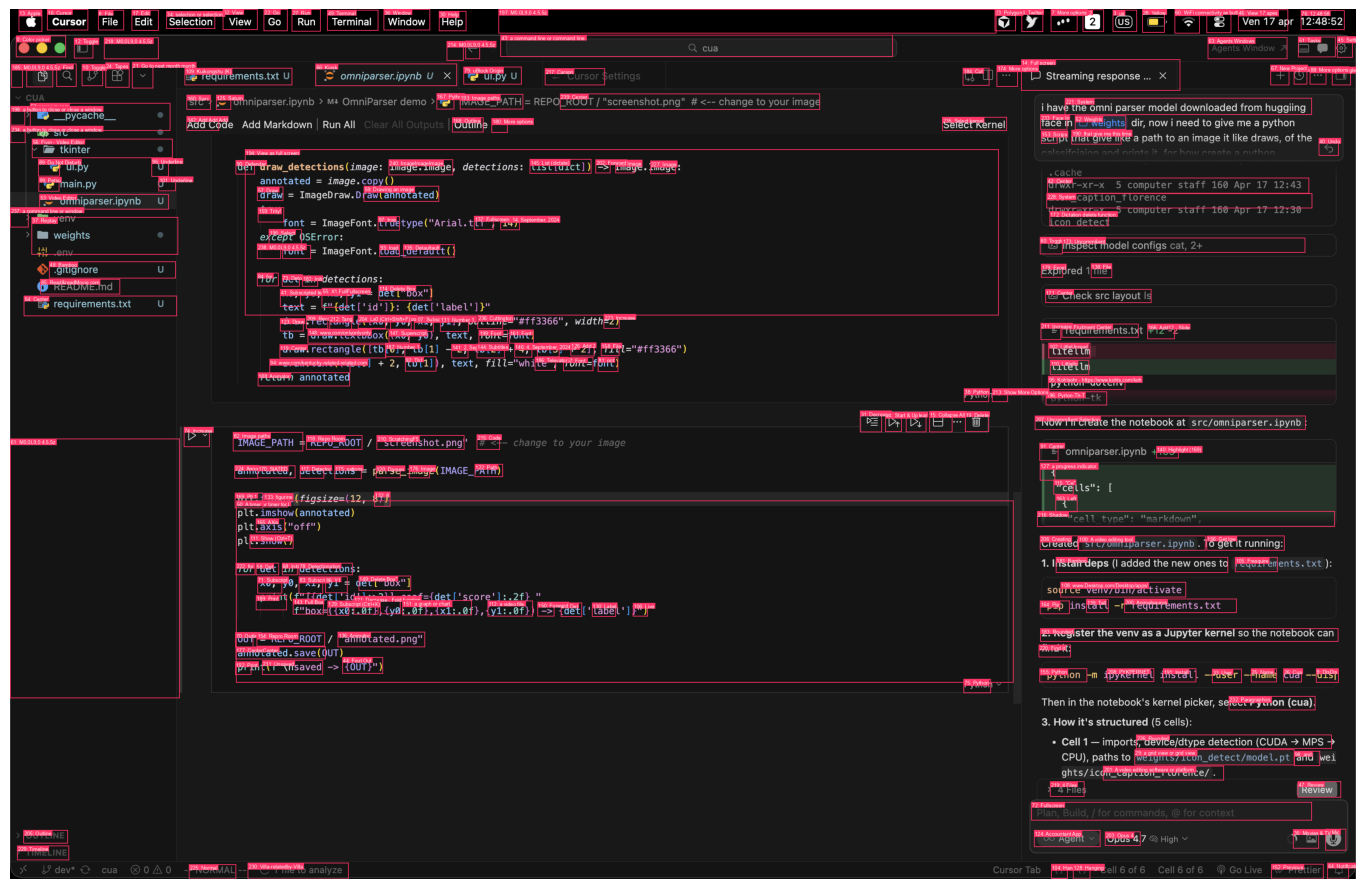

Detections: 241

 ID   CONF                BOX                 LABEL
------------------------------------------------------------------------
  0  0.748  (   15,   69,  143,  124)  Color picker
  1  0.715  (  120,  141,  171,  199)  Find
  2  0.712  ( 2755,    1, 2809,   58)  2
  3  0.689  ( 2831,    2, 2894,   59)  us
  4  0.670  ( 2597,    0, 2653,   59)  Twitter
  5  0.666  (   43,  142,  110,  200)  Copy
  6  0.626  ( 3377, 2105, 3431, 2160)  Mic
  7  0.625  ( 2673,    0, 2741,   59)  More options
  8  0.622  (  226,    3,  292,   55)  File
  9  0.613  ( 3353, 1693, 3412, 1730)  DisDis
 10  0.598  (  184,  141,  238,  198)  Toggle
 11  0.586  ( 3072,    0, 3135,   62)  Show button
 12  0.586  (  164,   74,  214,  127)  Toggle
 13  0.579  (   22,    2,   83,   58)  Apple
 14  0.577  ( 2596,  129, 3004,  210)  Full screen
 15  0.554  ( 2360, 1033, 2419, 1086)  Collapse All
 16  0.529  (   95,    1,  201,   54)  Cursor
 17  0.518  (  313,    2,  381,   56)  Edit
 18  0.516  ( 2300, 10

In [15]:
# ── Tune these before running ──────────────────────────────────────────────
IMAGE_PATH     = REPO_ROOT / "screenshot.png"  # path to your screenshot

BBOX_THRESHOLD = 0.01   # YOLO confidence (0-1), lower -> more boxes
IOU_THRESHOLD  = 0.01   # NMS IoU (0-1), lower -> fewer overlapping boxes
IMGSZ          = 640    # YOLO input size, e.g. 640 / 1024 / 1280 / None
# ───────────────────────────────────────────────────────────────────────────

annotated, detections = parse_image(
    IMAGE_PATH,
    bbox_threshold=BBOX_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
    imgsz=IMGSZ,
)

plt.figure(figsize=(14, 9))
plt.imshow(annotated)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Detections: {len(detections)}")
print()
print(f"{'ID':>3}  {'CONF':>5}  {'BOX':^32}  LABEL")
print("-" * 72)
for det in detections:
    x0, y0, x1, y1 = det["box"]
    print(f"{det['id']:>3}  {det['score']:.3f}  "
          f"({x0:>5.0f},{y0:>5.0f},{x1:>5.0f},{y1:>5.0f})  {det['label']}")

out_path = REPO_ROOT / "annotated.png"
annotated.save(out_path)
print(f"\nsaved -> {out_path}")